In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp  

In [25]:
P=3
alpha=0.001
mu0=4*np.pi*1e-7
mur=1
sigma=50499999.99999999
vol=2
N=3000
NPOD=50

In [26]:
# Select directory

directory="Results/OCC_dualbar/al_0.001_mu_1,1_sig_1e6,1e8/1e-3-1e12_"+str(N)+"_el_57195_ord_"+str(P)+"_POD_50_1e-6"



ck=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xi=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omega=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
time=np.genfromtxt(directory+'/Data/Time.csv', delimiter=',')
Sgn_step= np.genfromtxt(directory+'/Data/Sgn_step.csv', delimiter=',')
Sgn_impulse= np.genfromtxt(directory+'/Data/Sgn_impulse.csv', delimiter=',')
TensorArray= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvalues=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minf= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')

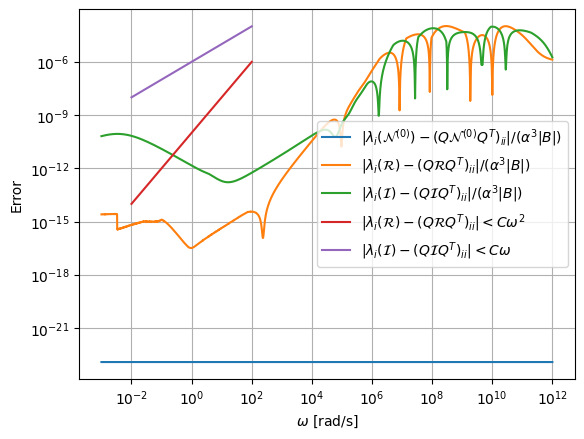

In [27]:
uinf,Qinf=np.linalg.eig(Minf)
myord=np.argsort(np.abs(uinf))
uinf=uinf[myord]
Qinf=Qinf[:,myord]

uN0,QN0=np.linalg.eig(N0)
myord=np.argsort(np.abs(uN0))
uN0=uN0[myord]
QN0=QN0[:,myord]
QN0=QN0[myord,:]

utest=np.transpose(Qinf)@np.real(N0)@Qinf
myord=np.argsort(np.diag(np.abs(utest)))
utest=utest[:,myord]
utest=utest[myord,:]

errorsN0=np.linalg.norm(uN0-np.diag(utest))*np.ones(len(Omega))
  

# Check the similarity of applying Qinf
errorsre=np.zeros(len(Omega))
errorsim=np.zeros(len(Omega))

for n in range(len(Omega)):
    lamre=np.real(Eigenvalues[n])
    Ten=TensorArray[n,:]
    MPT=np.zeros((3,3),dtype=complex)
    MPT[0,0]=Ten[0]
    MPT[0,1]=Ten[1]
    MPT[0,2]=Ten[2]
    MPT[1,0]=Ten[3]
    MPT[1,1]=Ten[4]
    MPT[1,2]=Ten[5]
    MPT[2,0]=Ten[6]
    MPT[2,1]=Ten[7]
    MPT[2,2]=Ten[8]
    ure,Qre=np.linalg.eig(np.real(MPT-N0))
    myord=np.argsort(np.abs(ure))
    ure=ure[myord]
    #Qre=Qre[:,myord]
    uim,Qim=np.linalg.eig(np.imag(MPT))
    myord=np.argsort(uim)
    uim=uim[myord]
    #Qim=Qim[:,myord]
    # Compare
    #print(MPT)
    utest=np.transpose(Qinf)@np.real(MPT-N0)@Qinf
    myord=np.argsort(np.diag(np.abs(utest)))
    utest=utest[:,myord]
    utest=utest[myord,:]
    
    #errorsre[n]=np.linalg.norm(np.diag(ure)-np.diag(np.diag(utest)))
    errorsre[n]=np.linalg.norm(ure-np.diag(utest))
    
    #print(errorsre[n]/alpha**3/vol,ure,np.diag(utest))
    
    utest=np.transpose(Qinf)@np.imag(MPT)@Qinf
    myord=np.argsort(np.diag(utest))
    utest=utest[:,myord]
    utest=utest[myord,:]
    
    errorsim[n]=np.linalg.norm(uim-np.diag(utest))
    #print(errorsim[n]/alpha**3/vol,uim,np.diag(utest))
    
plt.figure()
plt.loglog(Omega,errorsN0/alpha**3/vol,label=r"$| \lambda_i({\cal N}^{(0)})-(Q{\cal N}^{(0)} Q^T)_{ii}|/ (\alpha^3|B|)$")
plt.loglog(Omega,errorsre/alpha**3/vol,label=r"$| \lambda_i({\cal R})-(Q{\cal R} Q^T)_{ii}|/ (\alpha^3|B|)$")
plt.loglog(Omega,errorsim/alpha**3/vol,label=r"$| \lambda_i({\cal I})-(Q{\cal I} Q^T)_{ii}|/ (\alpha^3|B|)$")


#log error = 2*log omega +c
#c=log 1e-17-(log 1e-2)*2
c1=10**(np.log10(1e-14)-2*np.log10(1e-2))
line1=np.array(([[1e-2, 1e-14],[1e2, 10**(np.log10(1e2)*2+np.log10(c1) )]]))
plt.plot(line1[:,0],line1[:,1],label=r"$| \lambda_i({\cal R})-(Q{\cal R} Q^T)_{ii}|< C \omega^2$")
c2=10**(np.log10(1e-8)-np.log10(1e-2))
line2=np.array(([[1e-2, 1e-8],[1e2, 10**(np.log10(1e2)+np.log10(c2))]]))
plt.plot(line2[:,0],line2[:,1],label=r"$| \lambda_i({\cal I})-(Q{\cal I} Q^T)_{ii}|<  C \omega$")



plt.legend()
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"Error")
plt.grid()


3000
3000
3000


/tmp/user/10925/ipykernel_56123/3866256819.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))


<Figure size 640x480 with 0 Axes>

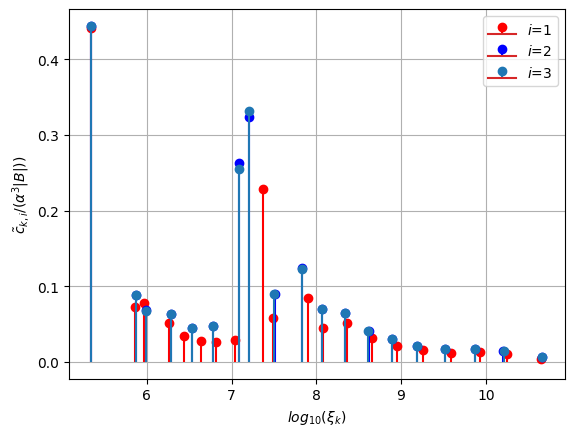

In [28]:
# Compare the modes and amplitudes
plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(xi[:,i])
    ckp=ck[0:nfound,i]
    xip=xi[0:nfound,i]
    print(nfound)
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))

    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B|))$')

plt.grid()
plt.legend()



/tmp/user/10925/ipykernel_56123/1034697751.py:10: RuntimeWarning: divide by zero encountered in divide
  DRSF+=ckp[n]/(1+1j*Omega/xip[n])
/tmp/user/10925/ipykernel_56123/1034697751.py:10: RuntimeWarning: invalid value encountered in divide
  DRSF+=ckp[n]/(1+1j*Omega/xip[n])


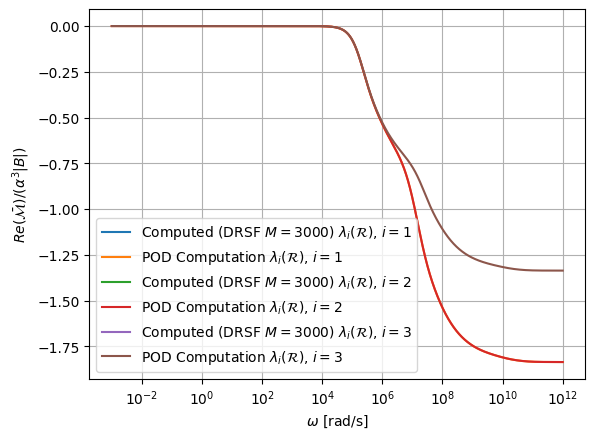

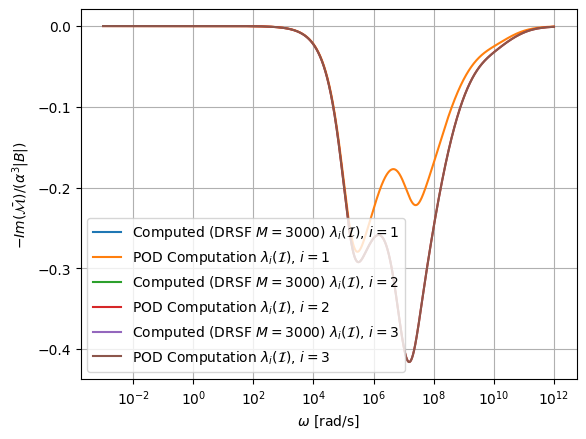

In [29]:
N=len(Omega)
for i in range(3):
    #DRSF=MPTinf_ob[i,i]*np.ones((N),dtype=complex)
    nfound=len(xi[:,0])
    ckp=ck[0:nfound,i]
    xip=xi[:,i]
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    DRSF=(ckp[0])*np.ones((N),dtype=complex)
    for n in range(1,nfound):
        DRSF+=ckp[n]/(1+1j*Omega/xip[n])
    plt.figure(1)
    plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),label=r"Computed (DRSF $M=3000$) $\lambda_i({\cal R})$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(Eigenvalues[:,i])/(alpha**3*vol),label=r"POD Computation $\lambda_i({\cal R})$, $i=$"+str(i+1))
    
    plt.figure(2)
    plt.semilogx(Omega,np.imag(DRSF)/(alpha**3*vol),label=r"Computed (DRSF $M=3000$) $\lambda_i({\cal I})$, $i=$"+str(i+1))
    plt.semilogx(Omega,-np.imag(Eigenvalues[:,i])/(alpha**3*vol),label=r"POD Computation $\lambda_i({\cal I})$, $i=$"+str(i+1))
                 
  
plt.figure(1)

plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Re(\bar{\cal M})/(\alpha^3|B|)$")
plt.grid()
plt.legend()
plt.savefig("my_plots/dualbar_mpt/mpt_dualbar_real_spectrum.pdf")


plt.figure(2)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$-Im(\bar{\cal M})/(\alpha^3|B|)$")
plt.legend()
plt.grid()
plt.savefig("my_plots/dualbar_mpt/mpt_dualbar_imag_spectrum.pdf")
plt.show()



<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/user/10925/ipykernel_56123/2695935205.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.semilogx(time,Sgn_step[:,i]/scale,label="Numerical Dual Bar step, $\lambda_i$, $i$="+str(i+1))


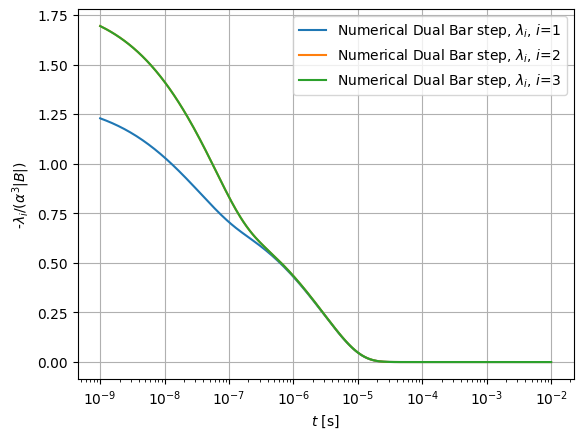

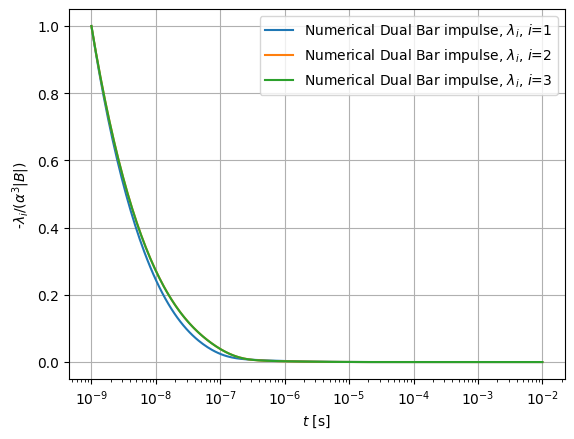

In [7]:
# Important note this is -lambda response as it tends to -1 for large time (ie -lambda(N0)(2*pi*alpha^3))
plt.figure(1)
scale=vol*alpha**3
for i in range(3):
    #scale=Sgn_step[0,i]
    plt.semilogx(time,Sgn_step[:,i]/scale,label="Numerical Dual Bar step, $\lambda_i$, $i$="+str(i+1))
plt.legend()
plt.grid()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"-$\lambda_i/(\alpha^3|B|)$")




plt.figure(2)
for i in range(3):
    scale=Sgn_impulse[0,i]
    plt.semilogx(time,Sgn_impulse[:,i]/scale,label=r"Numerical Dual Bar impulse, $\lambda_i$, $i$="+str(i+1))
    
plt.legend()
plt.grid()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"-$\lambda_i/(\alpha^3 |B|)$")
plt.show()


In [28]:
# Find ellipsoid from N0

In [29]:
from equiv_ellip import *
EvN0,QN0=np.linalg.eig(N0)      
order=np.argsort(-EvN0)
print(order)
EvN0=EvN0[order]
LamPS=np.zeros((3,3),dtype=float)
for i in range(3):
    LamPS[i,i]=EvN0[i]
print(LamPS)

[0 2 1]
[[1.25082366e-16 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.25082366e-16 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.25082366e-16]]


In [30]:
vol_ellip=(1+3/(mur-1))/(alpha**3*np.trace(np.linalg.inv(LamPS)))
print(vol,vol_ellip)
Hill=np.linalg.inv(LamPS)*alpha**3*vol_ellip-np.eye(3)/(mur-1)
print("Hill Tensor")
print(Hill)
if np.abs(np.trace(Hill)-1.) > 1e-12:
    print("Trace of Hill tensor is not 1",np.trace(Hill))
    old_trace=np.trace(Hill)
    Hill=Hill/old_trace
    print(Hill)

tol=None
ellip=find_ellipsoid(Hill,vol_ellip,tol)
print("Computed vol",4/3*np.pi*ellip[0]*ellip[1]*ellip[2])
PS,Hill=PStensor(ellip[0],ellip[1],ellip[2],alpha,mur,vol_ellip)
print("Tolerance=",tol,"Error in PS",np.linalg.norm(PS-LamPS)/np.linalg.norm(LamPS))

ZeroDivisionError: division by zero

In [31]:
# Find ellipsoid from Minf

In [32]:
print(Minf)
EvMinf,QMinf=np.linalg.eig(Minf)      
order=np.argsort(-EvMinf)
EvMinf=EvMinf[order]
LamPS=np.zeros((3,3),dtype=float)
for i in range(3):
    LamPS[i,i]=EvMinf[i]

print(LamPS)
# Find equivalent ellipsoid for infinite case
alphan=0.001
vol_ellip=(1+3/(0-1))/(alphan**3*np.trace(np.linalg.inv(LamPS)))
print("elliptic volume,",vol_ellip)
Hill=np.linalg.inv(LamPS)*alphan**3*vol_ellip-np.eye(3)/(0-1)
print("Hill Tensor")
print(Hill)
if np.abs(np.trace(Hill)-1.) > 1e-12:
    print("Trace of Hill tensor is not 1",np.trace(Hill))
    old_trace=np.trace(Hill)
    Hill=Hill/old_trace
    print(Hill)
tol=None
ellipinf=find_ellipsoid(Hill,vol_ellip,tol=tol)
PS,Hill=PStensor(ellipinf[0],ellipinf[1],ellipinf[2],alpha,0,vol_ellip)
print(PS)
print("Tolerance=",tol,"Error in PS",np.linalg.norm(PS-LamPS)/np.linalg.norm(LamPS))

[[-2.67278593e-09 -3.14535599e-14 -1.10992785e-13]
 [-3.14535599e-14 -3.67225754e-09  5.43179010e-15]
 [-1.10992785e-13  5.43179010e-15 -3.67217267e-09]]
[[-2.67278592e-09  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -3.67217234e-09  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -3.67225789e-09]]
elliptic volume, 2.176818968003243
Hill Tensor
[[0.18556179 0.         0.        ]
 [0.         0.4072122  0.        ]
 [0.         0.         0.40722601]]
solution to min problem [0.5323013  0.53231742]
Ellipsoid found is  [1.22405754 0.65158715 0.65156742]
0.185561792684768
PS Tensor
[[-2.67278591e-09 -0.00000000e+00 -0.00000000e+00]
 [-0.00000000e+00 -3.67217234e-09 -0.00000000e+00]
 [-0.00000000e+00 -0.00000000e+00 -3.67225789e-09]]
Hill Tensor
[[0.18556179 0.         0.        ]
 [0.         0.4072122  0.        ]
 [0.         0.         0.40722601]]
[[-2.67278591e-09 -0.00000000e+00 -0.00000000e+00]
 [-0.00000000e+00 -3.67217234e-09 -0.00000000e+00]
 [-0.00000000e+00 -0.0000000

In [33]:
"""from Functions.Core_Spectrum.getimpulse_step import *
"""

'from Functions.Core_Spectrum.getimpulse_step import *\n'

In [34]:
# remove scaling
"""TensorArrayn=TensorArray#/(2*np.pi*alpha**3)
Minfn = Minf #/(2*np.pi*alpha**3)

#Minfn=-1*np.eye(3)
xi_iter, ck_iter, Nfound_iter = PolesandAmp(Omega,np.conj(TensorArrayn),Minfn, Iterative_refine=False)
ck_iter=ck_iter#*(2*np.pi*alpha**3)"""

'TensorArrayn=TensorArray#/(2*np.pi*alpha**3)\nMinfn = Minf #/(2*np.pi*alpha**3)\n\n#Minfn=-1*np.eye(3)\nxi_iter, ck_iter, Nfound_iter = PolesandAmp(Omega,np.conj(TensorArrayn),Minfn, Iterative_refine=False)\nck_iter=ck_iter#*(2*np.pi*alpha**3)'

In [35]:
"""plt.figure()
col=['r','b','x']
plt.figure(1)
for i in range(3):
    nfound=len(xi_iter[:,i])
    ckp=ck_iter[0:nfound,i]
    xip=xi_iter[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')

plt.grid()
#plt.xlim(4,12)
plt.legend()
#plt.savefig("my_plots/sphere_mpt/modes_amp_iter_refine_Nfreq_"+str(N)+"_p_"+str(P)+"_POD_50_1e-6.pdf")

plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(xi[:,i])
    ckp=ck[0:nfound,i]
    xip=xi[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')
    

plt.grid()
#plt.xlim(4,12)
plt.legend()
#plt.savefig("my_plots/sphere_mpt/modes_amp_nnls_Nfreq_"+str(N)+"_p_"+str(P)+"_POD_"+str(NPOD)+"_1e-6.pdf")
plt.show()"""

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 270-271: truncated \xXX escape (1690172858.py, line 1)

In [39]:
# Compare tet and ellipsoid spectrums
# Gun
P=3
alpha=0.001
sigma=5.05e7
mur=1
mu0=4*np.pi*1e-7
vol=2
N=3000
NPOD=50

directory="Results/OCC_dualbar/al_0.001_mu_1,1_sig_1e6,1e8/1e-3-1e12_"+str(N)+"_el_57195_ord_"+str(P)+"_POD_50_1e-6"



ckobj=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xiobj=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omegaobj=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
TensorArrayobj= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvaluesobj=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minfobj= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0obj= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')

# Ellipsoid - minf
# Note this has been recalculated with linear geometry to ensure convergence of solution. Note issues with curved geometry and p>=5.
P=2
NPOD=50
directory="Results/OCC_ellipsoid_Dualbar_Minf/al_0.001_mu_1_sig_5.05e7/1e-3-1e12_"+str(N)+"_el_23316_ord_"+str(P)+"_POD_50_1e-6"

ckminf=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
ximinf=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omegaminf=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
TensorArrayminf= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvaluesminf=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minfminf= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0minf= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')

print(directory)

#Results/OCC_ellipsoid_Tetra_N0/al_0.001_mu_32_sig_1e7/1e-3-1e12_3000_el_17146_ord_3_POD_50_1e-6
P=2
NPOD=50
# no valid ellipsoid for N0 as mur=1
directory="Results/OCC_ellipsoid_Barrel_N0/al_0.01_mu_10_sig_4.5e6/1e-3-1e12_"+str(N)+"_el_49582_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"



ckn0=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xin0=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omegan0=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
TensorArrayn0= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvaluesn0=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minfn0= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0n0= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')


Results/OCC_ellipsoid_Dualbar_Minf/al_0.001_mu_1_sig_5.05e7/1e-3-1e12_3000_el_23316_ord_2_POD_50_1e-6


/tmp/user/10925/ipykernel_3017534/2791321274.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
/tmp/user/10925/ipykernel_3017534/2791321274.py:25: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
/tmp/user/10925/ipykernel_3017534/2791321274.py:45: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))


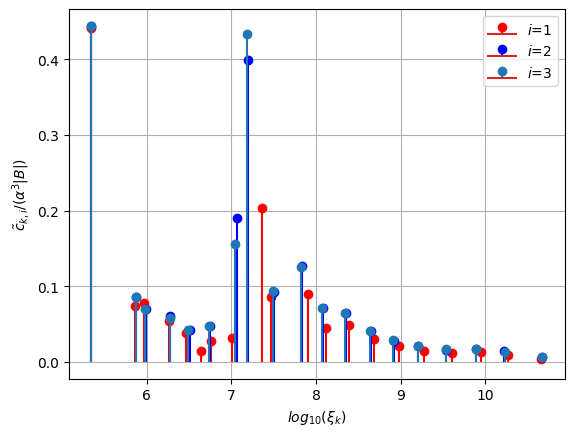

<Figure size 640x480 with 0 Axes>

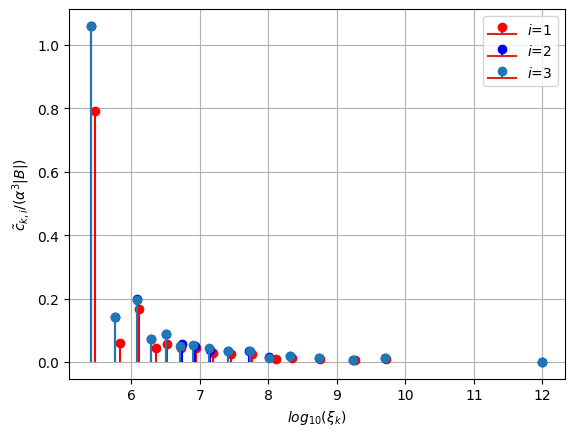

<Figure size 640x480 with 0 Axes>

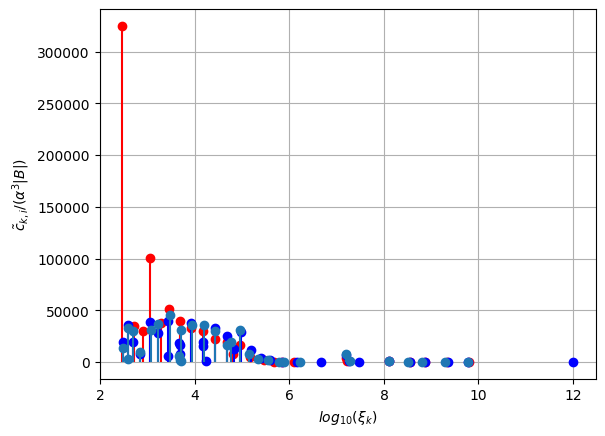

In [40]:
plt.figure()
col=['r','b','x']
plt.figure(1)
for i in range(3):
    nfound=len(xiobj[:,i])
    ckp=ckobj[0:nfound,i]
    xip=xiobj[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')

plt.grid()
#plt.xlim(4,12)
#plt.ylim(0,0.8)
plt.legend()
#plt.savefig("my_plots/sphere_mpt/modes_amp_iter_refine_Nfreq_"+str(N)+"_p_"+str(P)+"_POD_50_1e-6.pdf")

plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(ximinf[:,i])
    ckp=ckminf[0:nfound,i]
    xip=ximinf[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')
    
#print(ckminf)
plt.grid()
#plt.xlim(3,12)
#plt.ylim(0,0.8)

plt.legend()
#plt.savefig("my_plots/sphere_mpt/modes_amp_nnls_Nfreq_"+str(N)+"_p_"+str(P)+"_POD_"+str(NPOD)+"_1e-6.pdf")
#plt.show()

plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(xin0[:,i])
    ckp=ckn0[0:nfound,i]
    xip=xin0[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')
plt.grid()
#plt.xlim(4,12)
#plt.ylim(0,0.8)



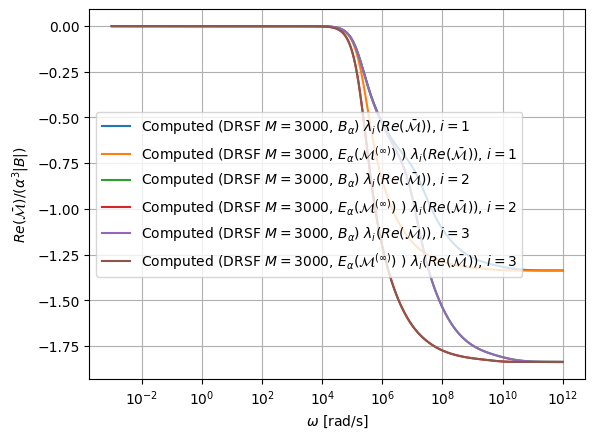

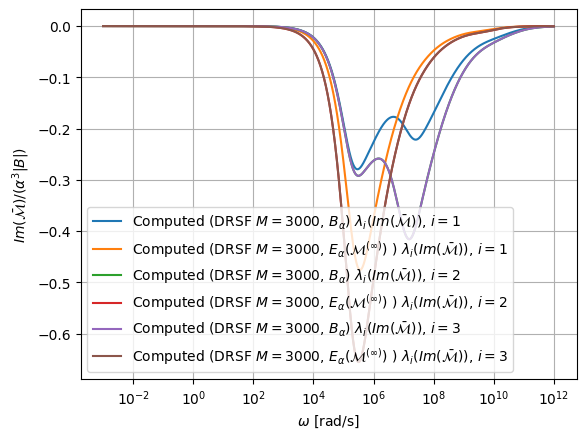

In [41]:
N=len(Omega)
for i in range(3):
    #DRSF=Minftet[i,i]*np.ones((N),dtype=complex)
    nfound=len(xiobj[:,i])
    ckp=ckobj[0:nfound,i]
    xip=xiobj[:,i]
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    DRSF=(ckp[0])*np.ones((N),dtype=complex)
    for n in range(1,nfound):
        if xip[n] != 0:
            DRSF+=ckp[n]/(1+1j*Omega/xip[n])
    #print(xitet)
    plt.figure(1)
    #plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),'x',label=r"Computed (DRSF $M=500$) $\lambda_i({\cal R})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,np.real(Eigenvaluestet[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))
    nfound=len(ximinf[:,i])
    ckp=ckminf[0:nfound,i]
    xip=ximinf[:,i]
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    #DRSFminf=(ckp[0])*np.ones((N),dtype=complex)
    DRSFminf=(ckp[0])*np.ones((N),dtype=complex)
    for n in range(1,nfound):
        if xip[n] != 0:
            DRSFminf+=ckp[n]/(1+1j*Omega/xip[n])

    nfound=len(xin0[:,i])
    ckp=ckn0[0:nfound,i]
    xip=xin0[:,i]
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    #DRSFn0=Minfn0[i,i]*np.ones((N),dtype=complex)
    DRSFn0=(ckp[0])*np.ones((N),dtype=complex)
    for n in range(1,nfound):
        if xip[n] != 0 :#and xip[n] < 1e10:
            DRSFn0+=ckp[n]/(1+1j*Omega/xip[n])
    
    plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $B_\alpha$) $\lambda_i(Re(\bar{\cal M}))$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(DRSFminf)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $E_\alpha({\cal M}^{(\infty)})$ ) $\lambda_i(Re(\bar{\cal M}))$, $i=$"+str(i+1))
    #plt.semilogx(Omega,np.real(DRSFn0)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $E_\alpha({\cal N}^{(0)})$) $\lambda_i(Re(\bar{\cal M}))$, $i=$"+str(i+1))
    
    #plt.semilogx(Omega,np.real(Eigenvaluesminf[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,np.real(Eigenvaluesn0[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))


    
    plt.figure(2)
    #plt.semilogx(Omega,-np.imag(Eigenvaluestet[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,-np.imag(Eigenvaluesminf[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,-np.imag(Eigenvaluesn0[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,np.imag(DRSFn0)/(alpha**3*vol),label=r"Computed (DRSF $M=500$) $\lambda_i({\cal I})$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.imag(DRSF)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $B_\alpha$) $\lambda_i(Im(\bar{\cal M}))$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.imag(DRSFminf)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $E_\alpha({\cal M}^{(\infty)})$ ) $\lambda_i(Im(\bar{\cal M}))$, $i=$"+str(i+1))
    #plt.semilogx(Omega,np.imag(DRSFn0)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $E_\alpha({\cal N}^{(0)})$) $\lambda_i(Im(\bar{\cal M}))$, $i=$"+str(i+1))
               
  
plt.figure(1)

plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Re(\bar{\cal M})/(\alpha^3|B|)$")
plt.grid()
plt.legend()


plt.figure(2)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Im(\bar{\cal M})/(\alpha^3|B|)$")
plt.legend()
plt.grid()
plt.show()

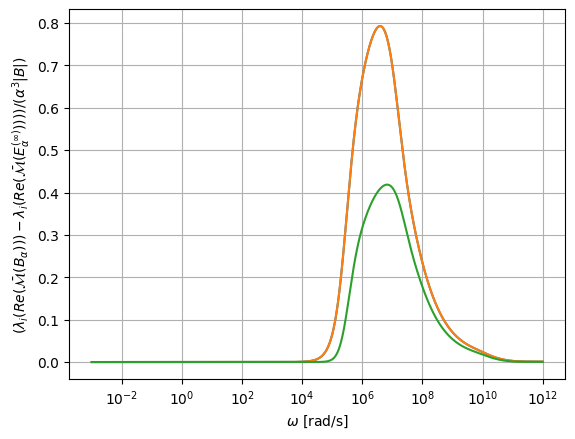

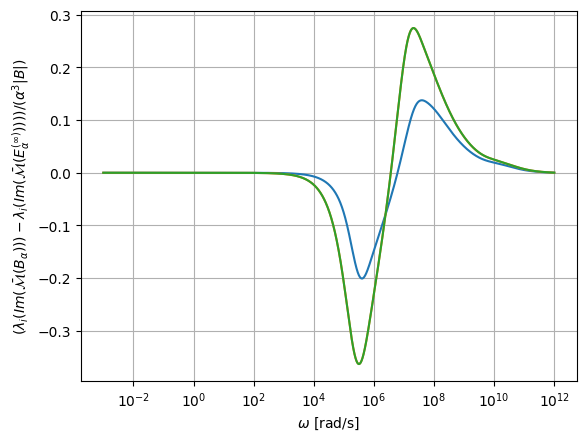

In [43]:

# Compute eigenvalues based on Q
for n in range(N):
    
    MPT=np.zeros((3,3),dtype=complex)
    MPT[0,0]=TensorArrayobj[n,0]
    MPT[0,1]=TensorArrayobj[n,1]
    MPT[0,2]=TensorArrayobj[n,2]
    MPT[1,0]=TensorArrayobj[n,3]
    MPT[1,1]=TensorArrayobj[n,4]
    MPT[1,2]=TensorArrayobj[n,5]
    MPT[2,0]=TensorArrayobj[n,6]
    MPT[2,1]=TensorArrayobj[n,7]
    MPT[2,2]=TensorArrayobj[n,8]
    reig,dum=np.linalg.eig(np.real(MPT))
    reig=np.sort(reig)
    ieig,dum=np.linalg.eig(np.imag(MPT))
    ieig=np.sort(ieig)
    
    Eigenvaluesobj[n,:]=reig+1j*ieig
    MPT[0,0]=TensorArrayminf[n,0]
    MPT[0,1]=TensorArrayminf[n,1]
    MPT[0,2]=TensorArrayminf[n,2]
    MPT[1,0]=TensorArrayminf[n,3]
    MPT[1,1]=TensorArrayminf[n,4]
    MPT[1,2]=TensorArrayminf[n,5]
    MPT[2,0]=TensorArrayminf[n,6]
    MPT[2,1]=TensorArrayminf[n,7]
    MPT[2,2]=TensorArrayminf[n,8]
    reig,dum=np.linalg.eig(np.real(MPT))
    reig=np.sort(reig)
    ieig,dum=np.linalg.eig(np.imag(MPT))
    ieig=np.sort(ieig)
    Eigenvaluesminf[n,:]=reig+1j*ieig
for i in range(3):    
    plt.figure(1)
    #plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),'x',label=r"Computed (DRSF $M=500$) $\lambda_i({\cal R})$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(Eigenvaluesobj[:,i])/(alpha**3*vol)-np.real(Eigenvaluesminf[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))

    
   
    plt.figure(2)
    plt.semilogx(Omega,np.imag(Eigenvaluesobj[:,i])/(alpha**3*vol)-np.imag(Eigenvaluesminf[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))

plt.figure(1)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$(\lambda_i ( Re(\bar{\cal M} (B_\alpha )) )- \lambda_i (Re(\bar{\cal M} ( E_\alpha^{( \infty) } ) )) ) /(\alpha^3 |B|)$")
plt.grid()

plt.figure(2)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$(\lambda_i ( Im(\bar{\cal M} (B_\alpha )) )- \lambda_i (Im(\bar{\cal M} ( E_\alpha^{( \infty) } ) ) )) /(\alpha^3 |B|)$")
plt.grid()




1.0000000000000018
10 10000000.0 [1.00000000e-01 1.00848139e-01 1.01703472e-01 ... 9.83250603e+09
 9.91589937e+09 1.00000000e+10]
Limit of omgea 79.67103030204055


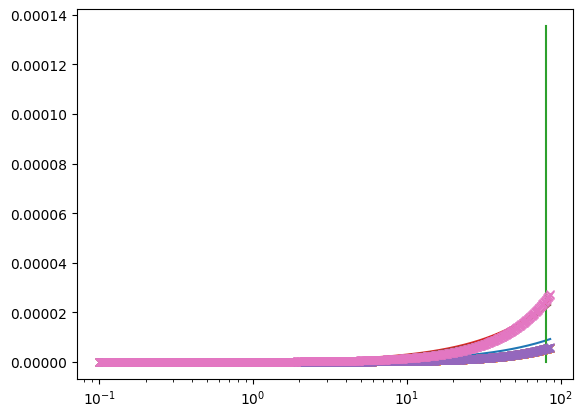

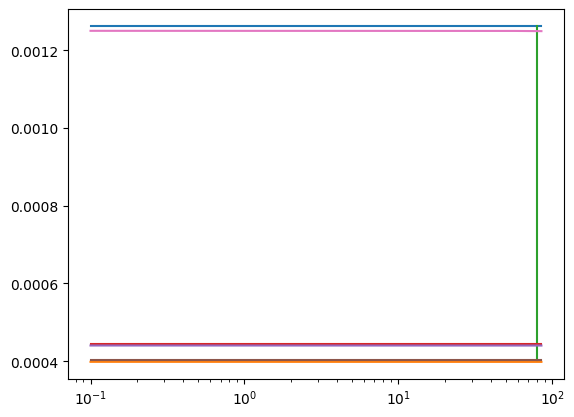

In [69]:
from scipy.integrate import quad
from equiv_ellip import *

# setting radius
a = 9.44758689
b = 2.61923538
c = 2.32539956

x1=b/a
x2=c/a
IA=quad(A,1,np.inf,args=(x1,x2))[0]
IB=quad(B,1,np.inf,args=(x1,x2))[0]
IC=quad(C,1,np.inf,args=(x1,x2))[0]
print(IA+IB+IC)

def myellip(a,b,c,mur,sigma,omega,A,B,C,alpha):
    vol=4/3*np.pi*a*b*c
    mu0=4*np.pi*1e-7
    De_mag = np.diag(((1/(1+A*(mur-1)),0,0),(0,1/(1+B*(mur-1)),0),(0,0,(1/(1+C*(mur-1)))))) 
    
    MPT_sig = -1j*omega*sigma*vol/20*np.array(((b**2+c**2,0,0),(0,a**2+c**2,0),(0,0,a**2+b**2)))*De_mag*mu0*alpha**5
    MPT_mu = vol*(mur-1)*De_mag*alpha**3
    return MPT_sig+MPT_mu

MPT_Ellip=np.zeros((len(Omega),3),dtype=complex)
cnt=0
print(mur,sigma,Omega)
for omega in Omega:
    m=np.diag(myellip(a,b,c,mur,sigma,omega,IA,IB,IC,alpha))
    #print(m,omega)
    MPT_Ellip[cnt,:]=m
    cnt+=1
for omega in Omega:
    k =np.abs(np.sqrt(1j*sigma*mur*mu0*omega))
    if k*alpha >=1:
        print("Limit of omgea",omega)
        omegal=omega
        break
        
plt.figure(1)
for i in range(3):
    plt.semilogx(Omega[0:800],-np.imag(MPT_Ellip[0:800,i]),)
    plt.semilogx(Omega[0:800],np.imag(Eigenvaluesn0[0:800,i]),'x')
    if i==0:
        plt.semilogx([omegal,omegal+1e-10],[np.min(-np.imag(MPT_Ellip[0:1000,0:3])),np.max(-np.imag(MPT_Ellip[0:1000,0:3]))])

plt.figure(2)
for i in range(3):
    plt.semilogx(Omega[0:800],np.real(MPT_Ellip[0:800,i]))
    plt.semilogx(Omega[0:800],np.real(Eigenvaluesn0[0:800,i]))
    if i==0:
        plt.semilogx([omegal,omegal+1e-10],[np.min((np.real(MPT_Ellip[0,0:3]))),np.max(np.real(MPT_Ellip[0,0:3]))])

plt.show()

In [23]:
[[0.00126265 0.         0.        ]
 [0.         0.00044444 0.        ]
 [0.         0.         0.00040166]]

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2505430073.py, line 1)

In [ ]:
[[0.12476986 0.         0.        ]
 [0.         0.41385438 0.        ]
 [0.         0.         0.46137576]]